In [6]:
import pandas as pd
import numpy as np
import pickle

In [7]:
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns
from sklearn.model_selection import ParameterGrid


In [12]:
test_qqq = pd.read_csv("../data/CLEAN/qqq_to_test.csv", index_col=0, parse_dates=True)
test_spy = pd.read_csv("../data/CLEAN/spy_to_test.csv", index_col=0, parse_dates=True)

In [13]:
test_spy

,daily_return,Volume_Ratio_lag_5,Volume_Change,ADX_14,Stoch_Oscillator,Volume,RSI_14_lag_3,Volatility_10d,Volume_Ratio,return_1d,...,RSI_14_lag_5,ATR_14,momentum_5d,Volume_lag_5,MACD_diff_lag_3,Volume_lag_3,month,weekday,SMA_50_was_imputed,target
Date,,,,,,,,,,,,,,,,,,,,,
2024-09-03,-0.020577,1.393218,-0.033493,35.233096,66.744419,60600100.0,73.822771,3.335136,1.307370,-0.016882,...,72.215995,7.803060,5.08,70328200.0,-0.443363,34439600.0,9,1,0,0
2024-09-04,-0.002048,1.185273,-0.220713,34.297658,62.979007,47224900.0,62.972384,4.250241,1.100945,-0.002047,...,68.671375,7.600699,6.44,64513900.0,-0.934645,39515800.0,9,2,0,0
2024-09-05,-0.002437,0.646152,-0.062692,33.128288,58.513829,44264300.0,71.403052,4.992127,0.986725,-0.002432,...,73.822771,7.536363,-4.17,34439600.0,-0.237243,32693900.0,9,3,0,0
2024-09-06,-0.016824,0.789767,0.547382,31.136593,4.067197,68493800.0,62.724326,7.356482,1.352152,-0.016830,...,62.972384,7.866623,-4.40,39515800.0,-0.507943,60600100.0,9,4,0,1
2024-09-09,0.011190,0.676916,-0.409497,29.287161,30.813439,40445800.0,61.760705,7.526653,0.774738,0.011196,...,71.403052,7.829721,-15.15,32693900.0,-0.837205,47224900.0,9,0,0,1
2024-09-10,0.004360,1.307370,-0.100164,27.724888,41.335102,36394600.0,60.572325,7.314449,0.768391,0.004356,...,62.724326,7.682598,-3.29,60600100.0,-1.197405,44264300.0,9,1,0,1
2024-09-11,0.010264,1.100945,1.067576,26.910160,66.224580,75248600.0,52.992193,6.710554,1.420605,0.010259,...,61.760705,8.233841,3.47,47224900.0,-2.060183,68493800.0,9,2,0,1
2024-09-12,0.008412,0.986725,-0.310383,26.530916,86.870027,51892700.0,56.800078,6.793244,0.952245,0.008423,...,60.572325,8.121424,9.48,44264300.0,-2.211633,40445800.0,9,3,0,1
2024-09-13,0.005236,1.352152,-0.242466,26.501104,95.676134,39310500.0,58.233417,7.235206,0.807887,0.005223,...,52.992193,7.822751,21.65,68493800.0,-2.138468,36394600.0,9,4,0,1


In [17]:
test_spy = test_spy.iloc[:-2]

In [14]:
test_qqq

,Volume_Ratio_lag_5,RSI_14_lag_5,volume_change,Volume_Ratio_lag_3,ADX_14,daily_return,rolling_std_5d,Volume_lag_1,Volume_Ratio_lag_1,momentum_10d,...,Volume_SMA_5,weekday,momentum_5d,RSI_14,MACD,return_3d,Open,month,MACD_diff_lag_3,target
Date,,,,,,,,,,,,,,,,,,,,,
2024-09-04,0.841218,84.296495,-0.277427,1.246163,50.143512,-0.002588,8.615484,49347400.0,1.334517,-19.65,...,38591020.0,2,-24.60,52.584302,0.404014,-0.021029,458.67,9,-0.717424,1
2024-09-05,1.172494,78.665518,0.059908,1.093625,47.140795,0.000938,9.646918,32505100.0,0.842297,-21.46,...,38697760.0,3,-20.43,52.887161,-0.303243,-0.032022,458.97,9,-1.577072,0
2024-09-06,1.246163,76.760861,0.469401,1.334517,44.244273,-0.026799,12.154409,34452400.0,0.890294,-26.16,...,40936060.0,4,-31.49,44.162393,-1.835102,-0.028450,460.33,9,-1.847345,1
2024-09-09,1.093625,68.188001,-0.348512,0.842297,41.554646,0.012873,11.578436,50624400.0,1.236670,-25.54,...,39982100.0,0,-19.50,48.441903,-2.555675,-0.012988,453.06,9,-3.287618,1
2024-09-10,1.334517,71.261093,-0.100084,0.890294,38.626266,0.009239,5.175487,32981200.0,0.824899,-16.68,...,36048680.0,1,-20.83,51.363928,-2.757654,-0.004687,456.24,9,-4.145913,1
2024-09-11,0.842297,52.584302,0.948868,1.236670,36.858243,0.021704,7.437021,29680300.0,0.823339,-8.14,...,41116260.0,2,8.01,57.513349,-2.093932,0.043816,459.91,9,-5.400580,1
2024-09-12,0.890294,52.887161,-0.305439,0.824899,35.623049,0.009818,10.084786,57843000.0,1.406816,1.87,...,42260880.0,3,12.18,60.027112,-1.184704,0.040761,468.65,9,-5.669231,1
2024-09-13,1.236670,44.162393,-0.275384,0.823339,34.686126,0.004479,9.127672,40175500.0,0.950655,4.68,...,37958360.0,4,26.65,61.167443,-0.290526,0.036000,472.48,9,-5.393054,0
2024-09-16,0.824899,48.441903,-0.224177,1.406816,33.501345,-0.004417,6.702841,29111800.0,0.766940,-3.03,...,35879240.0,0,18.78,59.360959,0.246629,0.009880,473.19,9,-4.409985,1


In [15]:
test_qqq.columns

Index(['Volume_Ratio_lag_5', 'RSI_14_lag_5', 'volume_change',
       'Volume_Ratio_lag_3', 'ADX_14', 'daily_return', 'rolling_std_5d',
       'Volume_lag_1', 'Volume_Ratio_lag_1', 'momentum_10d', 'MACD_diff',
       'momentum_3d', 'rolling_return_5d', 'Volume_Ratio', 'RSI_14_lag_3',
       'Volume_lag_5', 'Volume', 'MACD_diff_lag_5', 'Volatility_10d',
       'Price_Change', 'Stoch_Oscillator', 'momentum_7d', 'day', 'ATR_14',
       'Volume_lag_3', 'return_1d', 'Volume_SMA_5', 'weekday', 'momentum_5d',
       'RSI_14', 'MACD', 'return_3d', 'Open', 'month', 'MACD_diff_lag_3',
       'target'],
      dtype='object')

Change format

SIMULACION

/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warning

    day  invest_nasdaq  invest_sp500  return_nasdaq  return_sp500  \
0     1              1             0          -0.00          0.00   
1     2              1             1           0.00         -0.00   
2     3              1             0          -0.03          0.00   
3     4              1             0           0.01          0.00   
4     5              1             1           0.01          0.01   
5     6              0             0           0.00          0.00   
6     7              1             0           0.01          0.00   
7     8              1             1           0.00          0.01   
8     9              1             1          -0.00          0.01   
9    10              1             0           0.00          0.00   
10   11              0             0           0.00          0.00   
11   12              0             0           0.00          0.00   
12   13              0             0           0.00          0.00   
13   14              0            

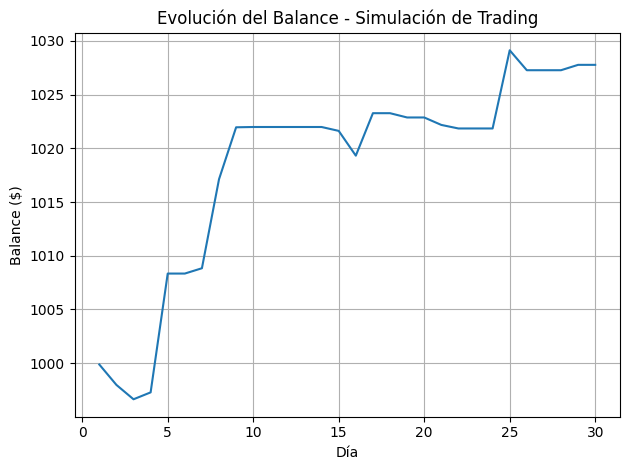

In [38]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Cargar modelos desde archivos .pkl
model_nasdaq = joblib.load("../models/GradBoost_QQQ.pkl")
model_sp500 = joblib.load("../models/XGBoost_SPY.pkl")

# Cargar los datos de prueba (30 días) — asegúrate de que estén alineados por fecha
test_nasdaq = pd.read_csv("../data/CLEAN/qqq_to_test.csv", parse_dates=["Date"], index_col="Date")   # Debe tener columnas: features, 'daily_return', 'target'
test_sp500 = pd.read_csv("../data/CLEAN/spy_to_test.csv", parse_dates=["Date"], index_col="Date")     # Igual formato

test_sp500 = test_sp500.iloc[:-2]

assert len(test_nasdaq) == len(test_sp500), "Las tablas deben tener el mismo número de filas"

# Parámetros
balance = 1000.0
weight_nasdaq = 0.05
weight_sp500 = 0.95

# Historial
log = []

for i in range(len(test_nasdaq)):
    day = i + 1

    # Features sin daily_return ni target
    features_nasdaq = test_nasdaq.drop(columns=['daily_return', 'target']).iloc[i]
    features_sp500 = test_sp500.drop(columns=['daily_return', 'target']).iloc[i]

    # Predicciones
    invest_nasdaq = model_nasdaq.predict([features_nasdaq])[0]
    invest_sp500 = model_sp500.predict([features_sp500])[0]

    # Capital invertido
    capital_nasdaq = balance * weight_nasdaq if invest_nasdaq == 1 else 0
    capital_sp500 = balance * weight_sp500 if invest_sp500 == 1 else 0

    # Retornos
    return_nasdaq = test_nasdaq['daily_return'].iloc[i] if invest_nasdaq == 1 else 0
    return_sp500 = test_sp500['daily_return'].iloc[i] if invest_sp500 == 1 else 0

    # Ganancias/pérdidas
    pnl_nasdaq = capital_nasdaq * return_nasdaq
    pnl_sp500 = capital_sp500 * return_sp500

    # Actualizar balance
    balance += pnl_nasdaq + pnl_sp500

    # Guardar día
    log.append({
        'day': day,
        'invest_nasdaq': invest_nasdaq,
        'invest_sp500': invest_sp500,
        'return_nasdaq': return_nasdaq,
        'return_sp500': return_sp500,
        'capital_nasdaq': capital_nasdaq,
        'capital_sp500': capital_sp500,
        'pnl_nasdaq': pnl_nasdaq,
        'pnl_sp500': pnl_sp500,
        'balance': balance
    })

# Convertir a DataFrame
log_df = pd.DataFrame(log)

# Mostrar
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(log_df)

# Guardar CSV (opcional)
log_df.to_csv("simulacion_trading.csv", index=False)

# Visualizar balance
plt.plot(log_df['day'], log_df['balance'])
plt.title("Evolución del Balance - Simulación de Trading")
plt.xlabel("Día")
plt.ylabel("Balance ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
test_sp500

,Date,daily_return,Volume_Ratio_lag_5,Volume_Change,ADX_14,Stoch_Oscillator,Volume,RSI_14_lag_3,Volatility_10d,Volume_Ratio,...,RSI_14_lag_5,ATR_14,momentum_5d,Volume_lag_5,MACD_diff_lag_3,Volume_lag_3,month,weekday,SMA_50_was_imputed,target
0,2024-09-03,-0.020577,1.393218,-0.033493,35.233096,66.744419,60600100.0,73.822771,3.335136,1.307370,...,72.215995,7.803060,5.08,70328200.0,-0.443363,34439600.0,9,1,0,0
1,2024-09-04,-0.002048,1.185273,-0.220713,34.297658,62.979007,47224900.0,62.972384,4.250241,1.100945,...,68.671375,7.600699,6.44,64513900.0,-0.934645,39515800.0,9,2,0,0
2,2024-09-05,-0.002437,0.646152,-0.062692,33.128288,58.513829,44264300.0,71.403052,4.992127,0.986725,...,73.822771,7.536363,-4.17,34439600.0,-0.237243,32693900.0,9,3,0,0
3,2024-09-06,-0.016824,0.789767,0.547382,31.136593,4.067197,68493800.0,62.724326,7.356482,1.352152,...,62.972384,7.866623,-4.40,39515800.0,-0.507943,60600100.0,9,4,0,1
4,2024-09-09,0.011190,0.676916,-0.409497,29.287161,30.813439,40445800.0,61.760705,7.526653,0.774738,...,71.403052,7.829721,-15.15,32693900.0,-0.837205,47224900.0,9,0,0,1
5,2024-09-10,0.004360,1.307370,-0.100164,27.724888,41.335102,36394600.0,60.572325,7.314449,0.768391,...,62.724326,7.682598,-3.29,60600100.0,-1.197405,44264300.0,9,1,0,1
6,2024-09-11,0.010264,1.100945,1.067576,26.910160,66.224580,75248600.0,52.992193,6.710554,1.420605,...,61.760705,8.233841,3.47,47224900.0,-2.060183,68493800.0,9,2,0,1
7,2024-09-12,0.008412,0.986725,-0.310383,26.530916,86.870027,51892700.0,56.800078,6.793244,0.952245,...,60.572325,8.121424,9.48,44264300.0,-2.211633,40445800.0,9,3,0,1
8,2024-09-13,0.005236,1.352152,-0.242466,26.501104,95.676134,39310500.0,58.233417,7.235206,0.807887,...,52.992193,7.822751,21.65,68493800.0,-2.138468,36394600.0,9,4,0,1
9,2024-09-16,0.001473,0.774738,-0.067524,26.480622,98.859316,36656100.0,61.488573,7.097649,0.765255,...,56.800078,7.493269,16.43,40445800.0,-1.716071,75248600.0,9,0,0,1
